I want to illustrate the fact that the standard Brownian motion has no drift and increasing variance, so the longer the time intervals, the wider possible spreads

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

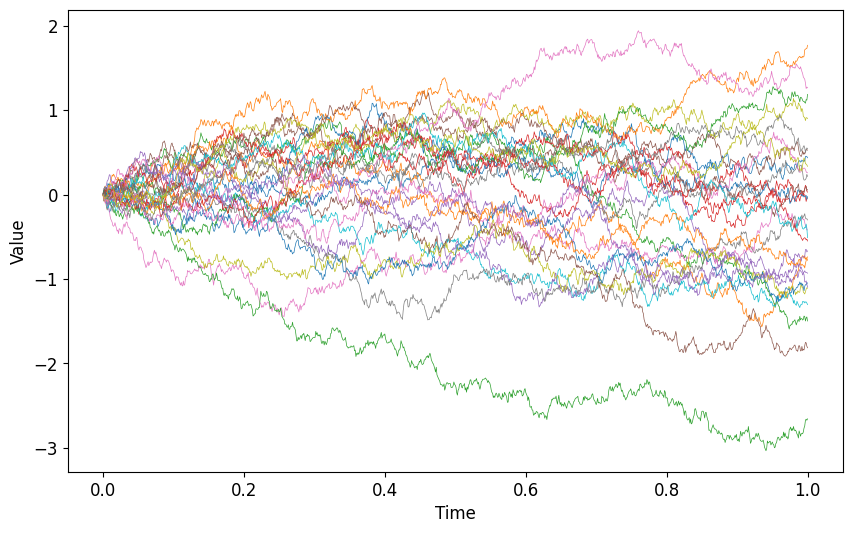

In [75]:
def sim_BM(T, Ndt, Nsims=10):
        
    # time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for the RW
    W = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    W[0,:] = 0
    
    # recursively simulate the process ( W[idx,:] is (1 , Nsims) )
    for i in range(Ndt):
        Z = np.random.normal(0,1,Nsims)
        W[i+1,:] = W[i,:] + np.sqrt(dt) * Z
    return time, W

#Parameters
T=1
Ndt = 1000
Npaths=100

#Seed
np.random.seed(123)

#Simulate
t, W = sim_BM(T,Ndt,Npaths)
   
# plot the sample paths
plt.figure(figsize=(10, 6))
plt.plot(t, W[:,1:30], linewidth=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

plt.savefig("BM_wealth_paths.pdf", bbox_inches="tight")

plt.show()

Illustration of Geometric Brownian Motion for the theory section

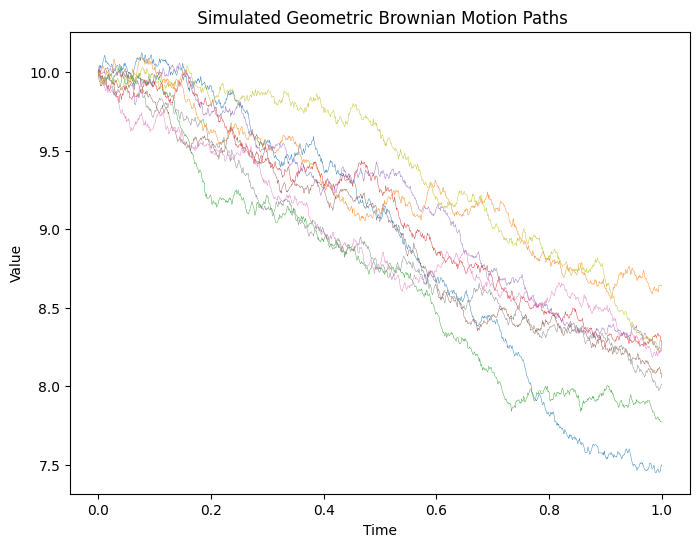

In [67]:
np.random.seed(123)

#Parameters
X0 = 10
mu = -0.2
sigma = 0.05
T = 1
Ndt = 1000
Nsims = 500

def simulate_GBM(X0, mu, sigma, T, Ndt, Nsims=10):
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for GBMs
    X = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    X[0,:] = X0
    
    # recursively simulate the process ( S[idx,:] is (1 , Nsims) )
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        # or Z = np.random.normal(0.0, 1.0, size=(1,Nsims))
        X[idx+1,:] = X[idx,:] * np.exp( (mu - (sigma**2)/2) * dt
                                      + sigma * np.sqrt(dt) * Z)
    
    return time, X

t, X = simulate_GBM(X0, mu, sigma, T, Ndt,Nsims)
   
# plot the sample paths
plt.figure(figsize=(8, 6))
plt.plot(t, X[:,1:10], linewidth=0.3)
plt.title(r" Simulated Geometric Brownian Motion Paths")
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()


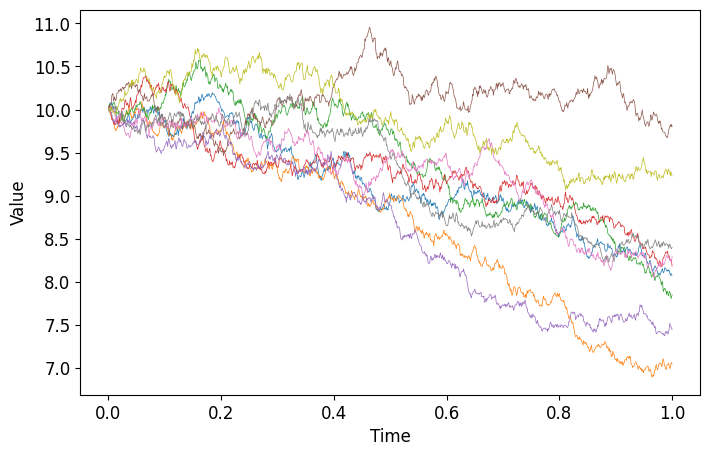

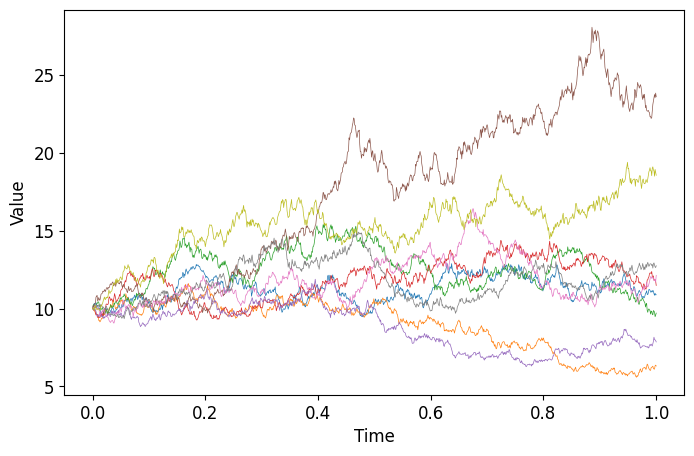

In [76]:
#Parameters
X0 = 10
mu1 = -0.2
mu2=0.2
sigma1 = 0.1
sigma2=0.4
T = 1
Ndt = 1000
Nsims = 500

def simulate_GBM(X0, mu, sigma, T, Ndt, Nsims=10):
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for GBMs
    X = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    X[0,:] = X0
    
    # recursively simulate the process ( S[idx,:] is (1 , Nsims) )
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        # or Z = np.random.normal(0.0, 1.0, size=(1,Nsims))
        X[idx+1,:] = X[idx,:] * np.exp( (mu - (sigma**2)/2) * dt
                                      + sigma * np.sqrt(dt) * Z)
    
    return time, X

np.random.seed(42)
t1, X1 = simulate_GBM(X0, mu1, sigma1, T, Ndt, Nsims)

np.random.seed(42)
t2, X2 = simulate_GBM(X0, mu2, sigma2, T, Ndt, Nsims)


plt.figure(figsize=(8, 5))
plt.plot(t1, X1[:,1:10], linewidth=0.5)
#plt.title(r" Simulated Geometric Brownian Motion Paths with $\mu=-0.2$ and $\sigma=0.1$")
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.savefig("GBM_paths1.pdf", bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(t2, X2[:,1:10], linewidth=0.5)
#plt.title(r" Simulated Geometric Brownian Motion Paths with $\mu=0.2$ and $\sigma=0.4$")
plt.xlabel('Time',fontsize=12)
plt.ylabel('Value',fontsize=12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.savefig("GBM_paths2.pdf", bbox_inches="tight")
plt.show()
